**Title**: Job Monitoring - Admin Version

**Date**:  July 9th 2020

**Description**:  
A simple tutorial about job monitoring for admin only. 

Topics that are included:
1. Jobs that I have launched
2. Filter jobs based on gear name, date range, and state
3. Cancelling Jobs
4. Restarting Jobs
5. Get summary of job status

Capture information about jobs: Execution time, queue time, by job, sorting, plots with information about the job id on hover 

### **Requirements**:
1. Access to a Flywheel instance.
3. A Flywheel API key.
2. A Flywheel Project with ideally the dataset used in the [upload-data notebook](https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb).
2. Site Admin Permission?
3. Have some jobs running in your Flywheel Project

<div class="alert alert-block alert-warning" >
    <b>NOTE:</b> This notebook is using a test dataset provided by the <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">upload-data notebook</a>. If you have not uploaded this test dataset yet, we strongly recommend you do so now following steps in <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">here</a> before proceeding because this notebook is based on a specific project structure.
</div>

<div class="alert alert-block alert-danger" >
    <b>WARNING:</b> The metadata of the acquisitions in your test project will be updated and new files will be created after running the scripts below. 
</div>

# Install and Import Dependencies

In [ ]:
# Install specific packages required for this notebook
!pip install flywheel-sdk pandas

In [1]:
# Import packages
from getpass import getpass
import logging
import os
import datetime
import time
import pprint
from dateutil.tz import tzutc

from IPython.display import display, Image
import flywheel
from permission import check_user_permission
import numpy as np
from tqdm import tqdm
import statistics as stats
from scipy import stats as st
import matplotlib.pyplot as plt
from scipy.stats import normaltest

In [2]:
# Instantiate a logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger('root')

# Flywheel API Key and Client

Get a API_KEY. More on this at in the Flywheel SDK doc [here](https://flywheel-io.gitlab.io/product/backend/sdk/branches/master/python/getting_started.html#api-key).

In [3]:
API_KEY = getpass('Enter API_KEY here: ')

Enter API_KEY here:  ····································


Instantiate the Flywheel API client

In [4]:
fw = flywheel.Client(API_KEY or os.environ.get('FW_KEY'))

Show Flywheel logging information

In [5]:
log.info('You are now logged in as %s to %s', fw.get_current_user()['email'], fw.get_config()['site']['api_url'])

2020-07-11 15:27:16,754 INFO You are now logged in as huiqiantan@flywheel.io to https://ss.ce.flywheel.io:443/api


***

# Check User Minimum Requirements

Before we started our section, we would like to verify that you have the right permission to proceed in this notebook. 


In [6]:
min_reqs = {
"site": "site_admin",
"group": "ro",
"project": ['jobs_view',
             'jobs_run_cancel',
             'jobs_cancel_any']
}

***

# Find Jobs

Firstly, we will show you how to find the jobs that you have run previously. 

In the example below, we will be getting 2 jobs that you have launched within your instance. You can change the number of jobs that will be returned by modified the `limit` variable.

In [16]:
user_id = fw.get_current_user()['email']

In [31]:
user_jobs = fw.jobs.find(f'origin.id={user_id}',limit = '2')

In [ ]:
pprint.pprint(user_jobs)

<div class="alert alert-block alert-info" style="color:black"><b>Info:</b>To learn more about the different attributes, please visit our SDK Docs <a href="https://flywheel-io.gitlab.io/product/backend/sdk/branches/master/python/flywheel.models.html?highlight=job#module-flywheel.models.job">here</a>. It will come in handy when you try to filter jobs.</div>

Essentially, you can search for the jobs that launched by other users as well. 


In [20]:
sample_id = input('Please enter the user\'s email address that you wished to search for:  ')

Please enter the user's email address that you wished to search for:   


In [ ]:
user_jobs = fw.jobs.find(f'origin.id={sample_id}',limit = '2')

In [ ]:
pprint.pprint(user_jobs)

***

# Filter jobs based on gear name, date range, and state

## Gear Name

In [23]:
gear_name = 'mriqc'

In [ ]:
mriqc_jobs = fw.jobs.find(f'gear_info.name={gear_name}', limit='2')


In [ ]:
pprint.pprint(mriqc_jobs)

## Date Range

In [28]:
created_by = '2020-07-01'

In [29]:
filtered_jobs = fw.jobs.find(f'created>{created_by}', limit='2')

In [ ]:
pprint.pprint(filtered_jobs)

## State

In [ ]:
state = 'complete'

In [ ]:
filtered_jobs = fw.jobs.find(f'state={state}', limit='2')

In [ ]:
pprint.pprint(filtered_jobs)

***

# Cancel Jobs

***

# Restart Jobs

***

# Statistics of the Jobs

In this section, we will be presenting some use case of job statsitcis or informations that you can plot them into graph. *NEED TO ADD MORE CONTENT IN HERE*

*VIEW Stats of Complete Jobs*

## Initialize a few values

In [12]:
def validate(date_text):
    try:
        datetime.datetime.strptime(date_text, '%Y-%m-%d')
        print('Please proceed to the next cell')
    except ValueError:
        raise ValueError("Incorrect data format, should be YYYY-MM-DD")

In [13]:
GEAR_NAME = input('Please enter the gear that you wish to print out the information about: ')
CREATED_BY = input('Please enter the date you wish to filter by in this format (yyyy-mm-dd): ')
MAX_SAMPLE_SIZE = input('Please enter the max number of jobs you want to analyze: ')

Please enter the gear that you wish to print out the information about:  mriqc
Please enter the date you wish to filter by in this format (yyyy-mm-dd):  2020-01-20
Please enter the max number of jobs you want to analyze:  10


In [14]:
# Verify if you have entered the right date format
validate(CREATED_BY)

Please proceed to the next cell


## Helpful Function

In [15]:
def plot(fw_client, gear_name, created_by, sample_size):
    run_times = list()
    
    for job in tqdm(fw_client.jobs.find(f'gear_info.name={gear_name},state="complete",created>{created_by}', limit=sample_size)):
        job_container = fw_client.get_job(job.id)
        time_delta = job_container.transitions.complete - job_container.transitions.running
        run_times.append(time_delta.total_seconds()/60)
        
    if run_times:
        plt.hist(run_times)
        plt.title(f'{gear_name} run times in minutes')
        plt.show()
        
        max_run_time = max(run_times) 
        min_run_time = min(run_times)
        run_time_range = max_run_time - min_run_time
        mu = stats.mean(run_times)
        sd = stats.stdev(run_times)

        # Determine a run_time_cutoff 
        s, pval = normaltest(run_times)
        if pval < 0.01:
            print(f's = {s:.2f}. Distribution is normal (enough)... Using 2*sd + mu a cutoff')
            run_time_cutoff = 2*sd + mu
        else:
            print(f's = {s:.2f}. Distribution is not normal (enough)... Using max time + 1sd as a cutoff')
            
            run_time_cutoff = max_run_time + 1*sd

        print(f'range={run_time_range:.2f}\nmu = {mu:.2f}\nsd = {sd:.2f}\ncut off = {run_time_cutoff:.2f}')
       

100%|██████████| 10/10 [00:00<00:00, 14.80it/s]


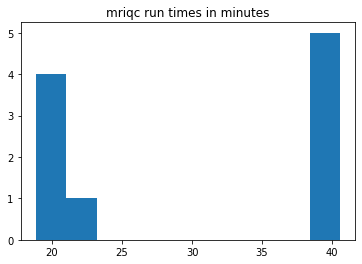

s = 11.16. Distribution is normal (enough)... Using 2*sd + mu a cutoff
range=21.74
mu = 29.86
sd = 10.16
cut off = 50.19


/Users/huiqiantan/opt/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1535: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  "anyway, n=%i" % int(n))


In [16]:
plot(fw, GEAR_NAME, CREATED_BY, MAX_SAMPLE_SIZE)

In [ ]:

sleep_time = 1              # Amount of time (in min) to sleep between checks

while True:
    print(f"==============================\n{datetime.datetime.now()}\n==============================\n")
   
    
    num_pending = len(fw.jobs.find(f'state=pending,created>{CREATED_BY},gear_info.name={GEAR_NAME}', limit=MAX_SAMPLE_SIZE))
    print(f'{num_pending} pending {GEAR_NAME} jobs')

    running_jobs = fw.jobs.find(f'state=running,created>{CREATED_BY},gear_info.name={GEAR_NAME}', limit=MAX_SAMPLE_SIZE)
    print(f'{running_jobs} running {GEAR_NAME} jobs\n')

    for j in running_jobs:
        job = fw.get_job(j.id)
        time_delta = datetime.datetime.now(tz=tzutc()) - job.transitions.running
        run_time_min = time_delta.total_seconds()/60
        print('{} running for {:.2f} min'.format(job.id, run_time_min))
        if run_time_min > run_time_cutoff:
            print(f"{job.id} running for {run_time_min} -- cancelled as it is more than the cutoff of {run_time_cutoff}")
            
    print(f'Sleeping {sleep_time} min...')
    time.sleep(60*sleep_time)

2020-07-11 15:43:33.477184

0 pending mriqc jobs
[] running mriqc jobs

Sleeping 1 min...
2020-07-11 15:44:33.679800

0 pending mriqc jobs
[] running mriqc jobs

Sleeping 1 min...
